### Hotel No-Show Analysis and Web App Dashboard

This notebook explores the `noshow.db` dataset for the Visa Manager AI Engineer Assessment.

**Business objective:** identify where hotel booking no-shows are concentrated, estimate revenue exposure, and create simple insights that can guide operational interventions.

### EDA Questions

The analysis focuses on practical business questions:

1. What is the overall no-show rate?
2. Which branches, platforms, rooms, countries, and customer types have higher no-show rates?
3. Are first-time customers riskier than returning customers?
4. Which segments create the largest estimated revenue exposure?
5. What simple risk-scoring logic can be used for the prototype?

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DB_PATH = Path("noshow.db")
DB_PATH.exists(), DB_PATH.resolve()

(True, WindowsPath('C:/Users/nujen/OneDrive/Desktop/yini/visa/noshow.db'))

### 1. Load Data

The code below opens the SQLite database, lists available tables, and loads the first table. If the database contains more than one table, change `TABLE_NAME` to the one containing the booking data.

In [2]:
conn = sqlite3.connect(DB_PATH)

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    conn,
)
tables

,name
0,booking_ml_scores
1,noshow


In [3]:
TABLE_NAME = tables.loc[0, "name"]

# Double quotes keep the query safe for table names with spaces or special characters.
df = pd.read_sql_query(f'SELECT * FROM "{TABLE_NAME}";', conn)

print(f"Loaded table: {TABLE_NAME}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
df.head()

Loaded table: booking_ml_scores
Rows: 119,391 | Columns: 31


,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children,first_time_flag,customer_type,party_size,price_band,eda_risk_score,eda_risk_level,ml_risk_logistic_regression,ml_risk_decision_tree,ml_risk_random_forest,ml_risk_extra_trees,ml_risk_gradient_boosting,risk_score,predicted_no_show_probability,risk_band,price_numeric,expected_revenue_at_risk
0,94113,0.000,Changi,November,June,25.000,June,27.000,Singapore,Yes,Single,492.980,Website,1.000,0.000,1.000,First-time,1.000,Low,0.370,Medium,0.427,0.432,0.439,0.409,0.325,0.439,0.439,Medium,492.980,216.478
1,86543,0.000,Orchard,August,November,28.000,November,29.000,Indonesia,Yes,King,"1,351.220",Website,2.000,0.000,1.000,First-time,2.000,High,0.346,Low,0.194,0.220,0.232,0.217,0.130,0.232,0.232,Low,"1,351.220",313.118
2,75928,0.000,Changi,March,February,7.000,February,11.000,India,Yes,Single,NaN,Agent,1.000,0.000,1.000,First-time,1.000,Unknown,0.371,Medium,0.327,0.302,0.385,0.363,0.261,0.385,0.385,Medium,NaN,0.000
3,66947,1.000,Orchard,September,October,1.000,October,3.000,China,Yes,Single,666.040,Website,1.000,0.000,1.000,First-time,1.000,Mid-low,0.349,Low,0.636,0.576,0.608,0.594,0.469,0.608,0.608,High,666.040,405.222
4,106390,0.000,Orchard,March,June,20.000,June,24.000,Australia,Yes,Queen,665.370,Website,1.000,0.000,1.000,First-time,1.000,Mid-low,0.348,Low,0.273,0.362,0.294,0.288,0.191,0.294,0.294,Low,665.370,195.382


In [4]:
schema = pd.read_sql_query(f'PRAGMA table_info("{TABLE_NAME}");', conn)
schema

,cid,name,type,notnull,dflt_value,pk
0,0,booking_id,INTEGER,0,None,0
1,1,no_show,REAL,0,None,0
2,2,branch,TEXT,0,None,0
3,3,booking_month,TEXT,0,None,0
4,4,arrival_month,TEXT,0,None,0
5,5,arrival_day,REAL,0,None,0
6,6,checkout_month,TEXT,0,None,0
7,7,checkout_day,REAL,0,None,0
8,8,country,TEXT,0,None,0
9,9,first_time,TEXT,0,None,0


In [5]:
df.shape

(119391, 31)

### 2. Data Quality Checks

Before analyzing patterns, check data types, missing values, duplicate bookings, and whether the target column is encoded as expected.

In [6]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique_values": df.nunique(dropna=True),
})

quality.sort_values("missing_pct", ascending=False)

,dtype,missing_count,missing_pct,unique_values
price,float64,24882,20.841,54248
price_numeric,float64,24882,20.841,54248
room,str,21613,18.103,4
num_adults,float64,11403,9.551,2
arrival_day,float64,1,0.001,31
branch,str,1,0.001,2
no_show,float64,1,0.001,2
first_time,str,1,0.001,2
checkout_month,str,1,0.001,12
arrival_month,str,1,0.001,12


In [7]:
duplicate_booking_ids = 0
if "booking_id" in df.columns:
    duplicate_booking_ids = df["booking_id"].duplicated().sum()

print(f"Duplicate booking_id rows: {duplicate_booking_ids:,}")
print("Target distribution:")
display(df["no_show"].value_counts(dropna=False).rename("count"))
display((df["no_show"].value_counts(normalize=True, dropna=False) * 100).rename("percent"))

Duplicate booking_id rows: 0
Target distribution:


no_show
0.000    75166
1.000    44224
NaN          1
Name: count, dtype: int64

no_show
0.000   62.958
1.000   37.041
NaN      0.001
Name: percent, dtype: float64

### 3. Simple Data Cleaning and Feature Preparation for EDA

This section standardizes obvious formatting issues and creates lightweight helper fields for business analysis. These are not final ML features yet; they are mainly for clearer EDA.

Key cleaning step: month-name columns are standardized so inconsistent values such as `MaY`, `JulY`, `JunE`, `OcTober`, and `ApriL` become `May`, `July`, `June`, `October`, and `April`.

In [8]:
eda = df.copy()

for col in ["no_show", "num_adults", "num_children", "arrival_day", "checkout_day"]:
    if col in eda.columns:
        eda[col] = pd.to_numeric(eda[col], errors="coerce")

# Standardize month names so values such as MaY, JulY, and JunE are grouped correctly.
month_columns = [col for col in ["booking_month", "arrival_month", "checkout_month"] if col in eda.columns]
for col in month_columns:
    month_text = eda[col].astype("string").str.strip().str.lower()
    eda[col] = month_text.str[:1].str.upper() + month_text.str[1:]
    eda.loc[month_text.isin(["", "nan", "none", "null"]), col] = np.nan

if "price" in eda.columns:
    # Handles numeric prices and text prices such as "$120", "SGD 120", or "1,200".
    price_text = eda["price"].astype(str).str.replace(r"[^0-9.\-]", "", regex=True)
    eda["price"] = pd.to_numeric(price_text, errors="coerce")

# Flag first-time vs returning customers, handling various text representations of boolean values.
if "first_time" in eda.columns:
    first_time_text = eda["first_time"].astype(str).str.strip().str.lower()
    first_time_flag = first_time_text.map({
        "1": 1, "1.0": 1, "true": 1, "yes": 1, "y": 1, "first-time": 1, "first time": 1,
        "0": 0, "0.0": 0, "false": 0, "no": 0, "n": 0, "returning": 0,
    })
    eda["first_time_flag"] = first_time_flag
    eda["customer_type"] = np.select(
        [eda["first_time_flag"].eq(1), eda["first_time_flag"].eq(0)],
        ["First-time", "Returning"],
        default="Unknown",
    )

# Create a new feature for total party size by summing adults and children, handling missing values as zero.
if {"num_adults", "num_children"}.issubset(eda.columns):
    eda["party_size"] = eda["num_adults"].fillna(0) + eda["num_children"].fillna(0)

if "price" in eda.columns and eda["price"].notna().sum() > 0:
    price_band_codes = pd.qcut(eda["price"], q=4, labels=False, duplicates="drop")
    price_band_labels = {0: "Low", 1: "Mid-low", 2: "Mid-high", 3: "High"}
    eda["price_band"] = price_band_codes.map(price_band_labels).fillna("Unknown")
elif "price" in eda.columns:
    eda["price_band"] = "Unknown"

eda.head()

,booking_id,no_show,branch,booking_month,arrival_month,arrival_day,checkout_month,checkout_day,country,first_time,room,price,platform,num_adults,num_children,first_time_flag,customer_type,party_size,price_band,eda_risk_score,eda_risk_level,ml_risk_logistic_regression,ml_risk_decision_tree,ml_risk_random_forest,ml_risk_extra_trees,ml_risk_gradient_boosting,risk_score,predicted_no_show_probability,risk_band,price_numeric,expected_revenue_at_risk
0,94113,0.000,Changi,November,June,25.000,June,27.000,Singapore,Yes,Single,492.980,Website,1.000,0.000,1.000,First-time,1.000,Low,0.370,Medium,0.427,0.432,0.439,0.409,0.325,0.439,0.439,Medium,492.980,216.478
1,86543,0.000,Orchard,August,November,28.000,November,29.000,Indonesia,Yes,King,"1,351.220",Website,2.000,0.000,1.000,First-time,2.000,High,0.346,Low,0.194,0.220,0.232,0.217,0.130,0.232,0.232,Low,"1,351.220",313.118
2,75928,0.000,Changi,March,February,7.000,February,11.000,India,Yes,Single,NaN,Agent,1.000,0.000,1.000,First-time,1.000,Unknown,0.371,Medium,0.327,0.302,0.385,0.363,0.261,0.385,0.385,Medium,NaN,0.000
3,66947,1.000,Orchard,September,October,1.000,October,3.000,China,Yes,Single,666.040,Website,1.000,0.000,1.000,First-time,1.000,Mid-low,0.349,Low,0.636,0.576,0.608,0.594,0.469,0.608,0.608,High,666.040,405.222
4,106390,0.000,Orchard,March,June,20.000,June,24.000,Australia,Yes,Queen,665.370,Website,1.000,0.000,1.000,First-time,1.000,Mid-low,0.348,Low,0.273,0.362,0.294,0.288,0.191,0.294,0.294,Low,665.370,195.382


### 4. Executive KPIs

These are the headline numbers a business stakeholder would care about.

In [9]:
total_bookings = len(eda)
no_show_rate = eda["no_show"].mean()
show_rate = 1 - no_show_rate
avg_price = eda["price"].mean() if "price" in eda.columns else np.nan
observed_revenue_at_risk = eda.loc[eda["no_show"].eq(1), "price"].sum() if "price" in eda.columns else np.nan

kpis = pd.DataFrame({
    "Metric": [
        "Total bookings",
        "Overall no-show rate",
        "Overall show rate",
        "Average booking price",
        "Observed revenue at risk from no-shows",
    ],
    "Value": [
        f"{total_bookings:,}",
        f"{no_show_rate:.1%}",
        f"{show_rate:.1%}",
        f"{avg_price:,.2f}",
        f"{observed_revenue_at_risk:,.2f}",
    ],
})

kpis

,Metric,Value
0,Total bookings,"119,391"
1,Overall no-show rate,37.0%
2,Overall show rate,63.0%
3,Average booking price,821.18
4,Observed revenue at risk from no-shows,"28,108,323.54"


### 5. Segment Analysis

The helper below ranks each segment by booking volume, no-show rate, and observed revenue exposure.

In [10]:
def summarize_segment(data, column, min_bookings=20):
    summary = (
        data.groupby(column, dropna=False)
        .agg(
            bookings=("no_show", "size"),
            no_shows=("no_show", "sum"),
            no_show_rate=("no_show", "mean"),
            avg_price=("price", "mean") if "price" in data.columns else ("no_show", "mean"),
            observed_revenue_at_risk=("price", lambda s: s[data.loc[s.index, "no_show"].eq(1)].sum()) if "price" in data.columns else ("no_show", "sum"),
        )
        .reset_index()
    )
    summary["booking_share"] = summary["bookings"] / len(data)
    return summary.loc[summary["bookings"] >= min_bookings].sort_values(
        ["no_show_rate", "bookings"], ascending=[False, False]
    )

segment_columns = [
    col for col in ["branch", "platform", "country", "room", "customer_type", "booking_month", "arrival_month", "price_band"]
    if col in eda.columns
]

segment_columns

['branch',
 'platform',
 'country',
 'room',
 'customer_type',
 'booking_month',
 'arrival_month',
 'price_band']

In [11]:
for col in segment_columns:
    print(f"\nTop no-show segments by {col}")
    display(summarize_segment(eda, col).head(10))


Top no-show segments by branch


,branch,bookings,no_shows,no_show_rate,avg_price,observed_revenue_at_risk,booking_share
0,Changi,79330,"33,102.000",0.417,716.704,"19,100,240.420",0.664
1,Orchard,40060,"11,122.000",0.278,"1,029.680","9,008,083.120",0.336



Top no-show segments by platform


,platform,bookings,no_shows,no_show_rate,avg_price,observed_revenue_at_risk,booking_share
1,Email,32608,"12,214.000",0.375,821.726,"7,766,027.790",0.273
0,Agent,21735,"8,039.000",0.370,818.422,"5,100,880.600",0.182
3,Website,54234,"20,050.000",0.370,821.505,"12,755,338.730",0.454
2,Phone,10813,"3,921.000",0.363,823.451,"2,486,076.420",0.091



Top no-show segments by country


...

,booking_month,bookings,no_shows,no_show_rate,avg_price,observed_revenue_at_risk,booking_share
6,June,10324,"4,225.000",0.409,815.117,"2,722,661.790",0.086
5,July,9993,"3,956.000",0.396,810.901,"2,508,530.490",0.084
0,April,9571,"3,750.000",0.392,818.800,"2,379,219.460",0.080
11,September,10315,"3,949.000",0.383,816.672,"2,455,468.680",0.086
2,December,9561,"3,579.000",0.374,821.018,"2,264,872.990",0.080
7,March,9754,"3,553.000",0.364,822.676,"2,271,233.960",0.082
1,August,10134,"3,678.000",0.363,823.757,"2,340,237.790",0.085
10,October,10068,"3,640.000",0.362,827.762,"2,329,175.320",0.084
9,November,10280,"3,677.000",0.358,832.285,"2,370,132.610",0.086
8,May,9588,"3,388.000",0.353,818.439,"2,159,237.730",0.080



Top no-show segments by arrival_month


,arrival_month,bookings,no_shows,no_show_rate,avg_price,observed_revenue_at_risk,booking_share
6,June,10939,"4,535.000",0.415,802.946,"2,882,314.950",0.092
0,April,11089,"4,524.000",0.408,806.962,"2,769,299.400",0.093
8,May,11791,"4,677.000",0.397,799.406,"2,898,662.750",0.099
11,September,10508,"4,116.000",0.392,817.475,"2,630,735.060",0.088
10,October,11160,"4,246.000",0.380,826.555,"2,713,602.780",0.093
1,August,13877,"5,239.000",0.378,810.937,"3,358,141.610",0.116
5,July,12661,"4,742.000",0.375,813.323,"3,029,320.480",0.106
2,December,6780,"2,371.000",0.350,843.933,"1,523,217.140",0.057
3,February,8068,"2,696.000",0.334,850.233,"1,774,474.320",0.068
7,March,9794,"3,149.000",0.322,821.844,"1,995,423.920",0.082



Top no-show segments by price_band


,price_band,bookings,no_shows,no_show_rate,avg_price,observed_revenue_at_risk,booking_share
2,Mid-high,23629,"9,494.000",0.402,889.506,"8,436,294.240",0.198
3,Mid-low,23624,"9,477.000",0.401,703.585,"6,654,995.190",0.198
4,Unknown,24882,"9,251.000",0.372,NaN,0.000,0.208
1,Low,23631,"8,664.000",0.367,523.405,"4,598,113.820",0.198
0,High,23625,"7,338.000",0.311,"1,168.291","8,418,920.290",0.198


### 6. Visual Analysis

These charts are designed to be easy to explain in a presentation or README.

In [12]:
def plot_top_no_show_rate(data, column, top_n=12, min_bookings=20):
    summary = summarize_segment(data, column, min_bookings=min_bookings).head(top_n)
    if summary.empty:
        print(f"No segments for {column} with at least {min_bookings} bookings.")
        return

    plt.figure(figsize=(10, 5))
    if sns:
        sns.barplot(data=summary, y=column, x="no_show_rate", color="#3b82f6")
    else:
        plt.barh(summary[column].astype(str), summary["no_show_rate"])
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    plt.title(f"Top {top_n} No-Show Rates by {column}")
    plt.xlabel("No-show rate")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

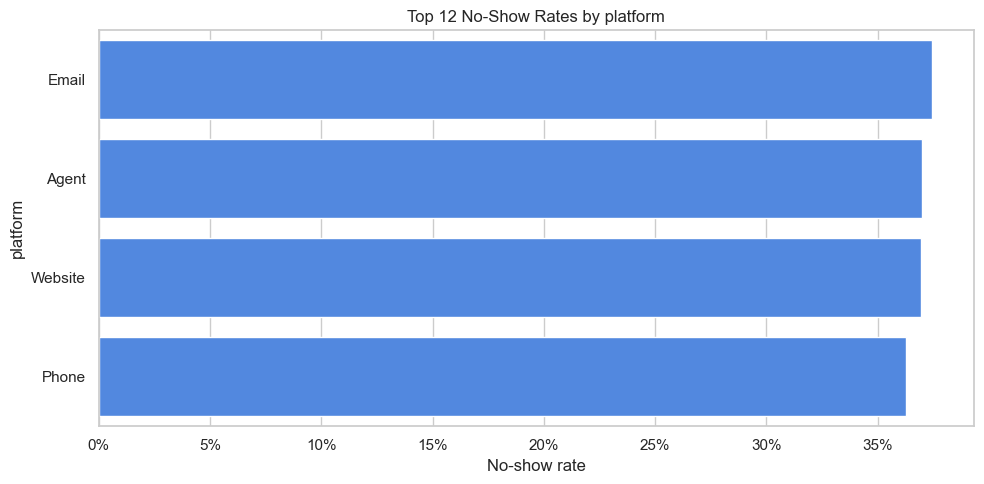

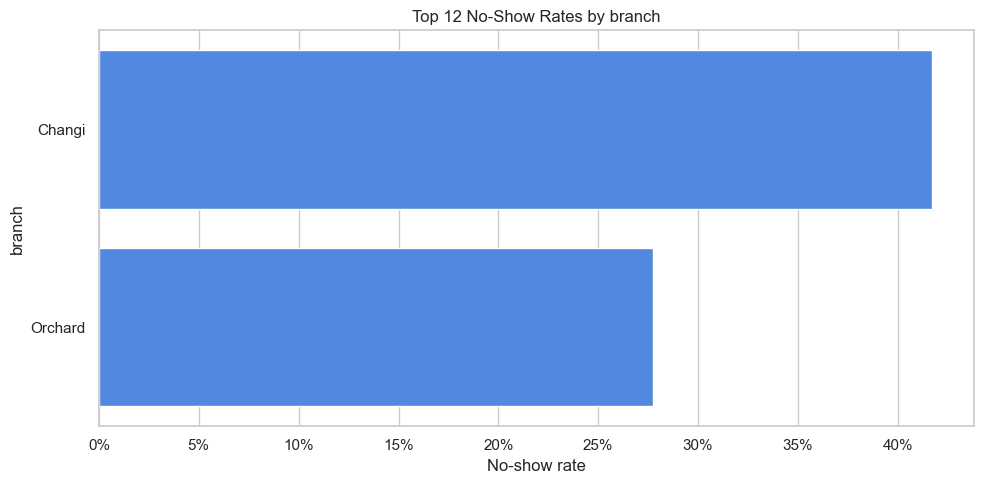

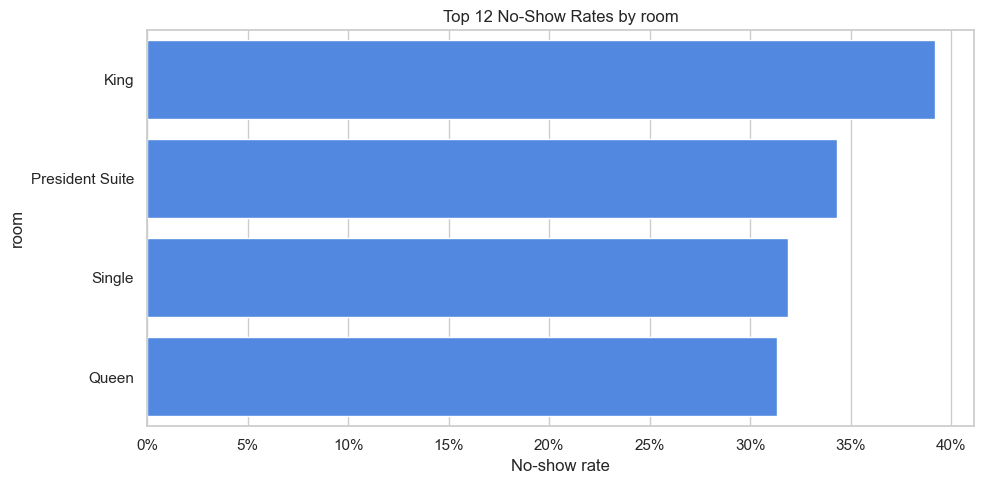

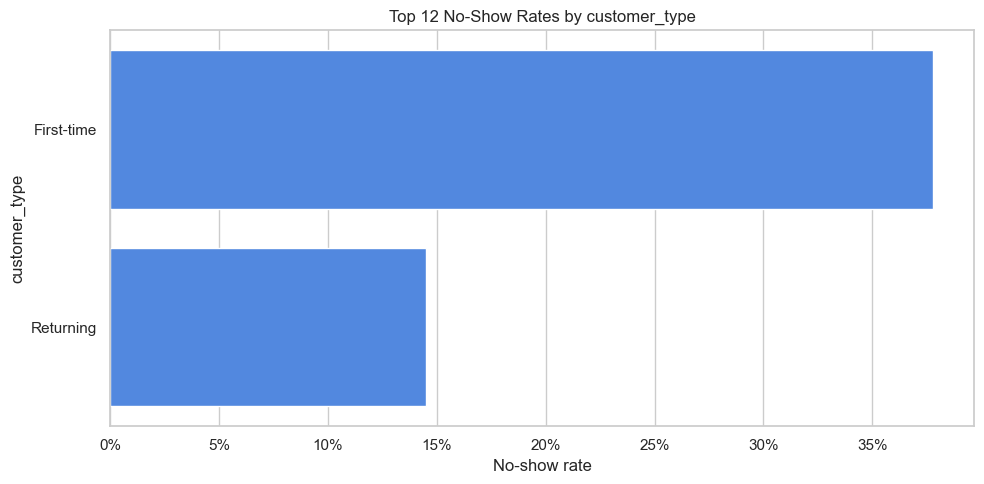

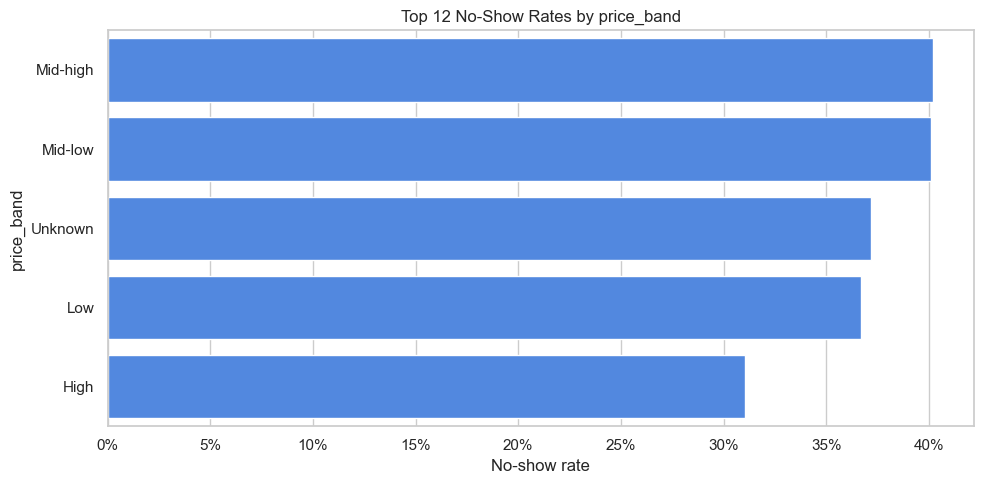

In [13]:
for col in ["platform", "branch", "room", "customer_type", "price_band"]:
    if col in eda.columns:
        plot_top_no_show_rate(eda, col, top_n=12, min_bookings=20)

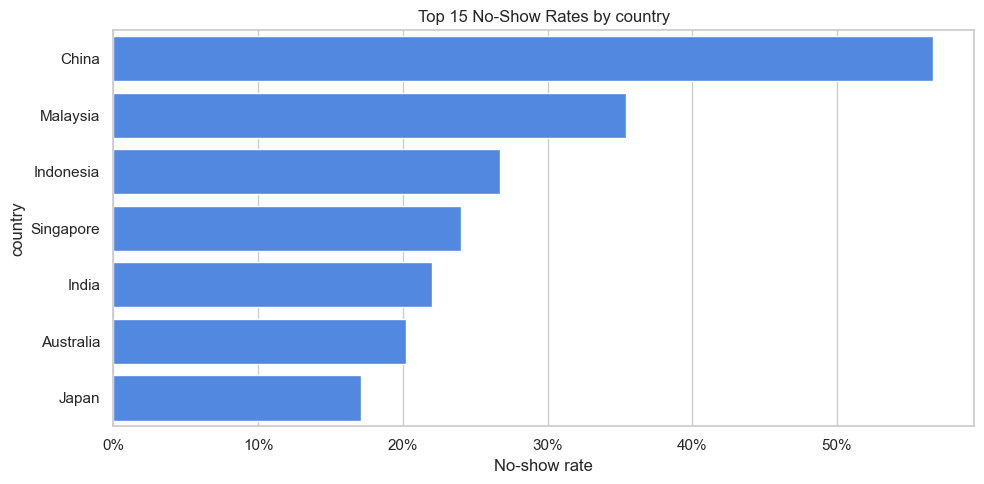

In [14]:
if "country" in eda.columns:
    plot_top_no_show_rate(eda, "country", top_n=15, min_bookings=50)

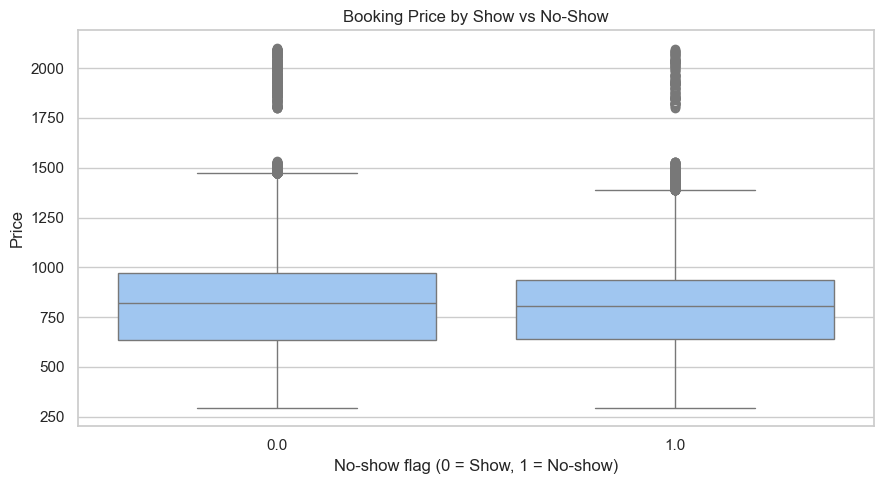

In [15]:
if "price" in eda.columns:
    price_plot_data = eda[["no_show", "price"]].dropna()

    if price_plot_data.empty or price_plot_data["price"].nunique() < 2:
        print("Skipping price chart: price has no usable numeric variation after cleaning.")
    else:
        plt.figure(figsize=(9, 5))
        if sns:
            sns.boxplot(data=price_plot_data, x="no_show", y="price", color="#93c5fd")
        else:
            price_plot_data.boxplot(column="price", by="no_show")
        plt.title("Booking Price by Show vs No-Show")
        plt.xlabel("No-show flag (0 = Show, 1 = No-show)")
        plt.ylabel("Price")
        plt.tight_layout()
        plt.show()

### 7. Revenue at Risk Exposure

Revenue at risk represent the revenue lost due to no-shows

`expected_revenue_at_risk = price * predicted_no_show_probability`

In [16]:
if "price" in eda.columns:
    revenue_views = []
    for col in ["branch", "platform", "room", "customer_type", "country"]:
        if col in eda.columns:
            temp = summarize_segment(eda, col, min_bookings=20)
            temp["dimension"] = col
            temp = temp.rename(columns={col: "segment"})
            revenue_views.append(temp[["dimension", "segment", "bookings", "no_show_rate", "observed_revenue_at_risk"]])

    revenue_exposure = pd.concat(revenue_views, ignore_index=True).sort_values(
        "observed_revenue_at_risk", ascending=False
    )
    revenue_exposure.head(20)

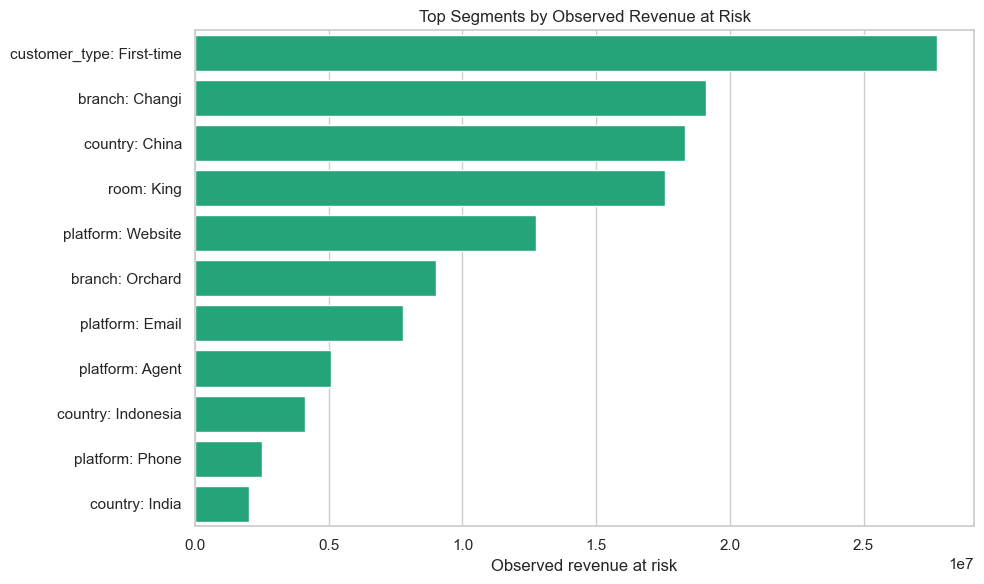

In [17]:
if "price" in eda.columns and "revenue_exposure" in globals():
    top_revenue = revenue_exposure.head(12).copy()
    top_revenue["label"] = top_revenue["dimension"] + ": " + top_revenue["segment"].astype(str)

    plt.figure(figsize=(10, 6))
    if sns:
        sns.barplot(data=top_revenue, y="label", x="observed_revenue_at_risk", color="#10b981")
    else:
        plt.barh(top_revenue["label"], top_revenue["observed_revenue_at_risk"])
    plt.title("Top Segments by Observed Revenue at Risk")
    plt.xlabel("Observed revenue at risk")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

### 8. Simple EDA Risk Score

This risk score is a simple estimate based on past no-show patterns.

For each booking, we look at its categories, such as platform, branch, room, customer type, and price band. For each category, we find the average no-show rate from past data. The final risk score is the sum of these average no-show rates.

A higher score means the booking belongs to groups that have historically had more no-shows.

The score is converted into **Low**, **Medium**, and **High** risk using dataset-relative quantiles. This is better than fixed cutoffs like 20% and 40% because the dataset's no-show rates may be tightly clustered around the average.

In [18]:
risk_features = [col for col in ["platform", "branch", "room", "customer_type", "price_band"] if col in eda.columns]

risk_score = pd.Series(0.0, index=eda.index)
for col in risk_features:
    rates = eda.groupby(col, dropna=False)["no_show"].mean()
    risk_score += eda[col].map(rates).fillna(no_show_rate)

eda["eda_risk_score"] = risk_score / max(len(risk_features), 1)

# Labels the lowest-scoring bookings as Low risk, the middle group as Medium,
# and the highest-scoring bookings as High risk based on this dataset's own distribution.
try:
    eda["eda_risk_level"] = pd.qcut(
        eda["eda_risk_score"],
        q=3,
        labels=["Low", "Medium", "High"],
        duplicates="drop",
    )
except ValueError:
    eda["eda_risk_level"] = pd.cut(
        eda["eda_risk_score"],
        bins=3,
        labels=["Low", "Medium", "High"],
        include_lowest=True,
    )

eda[["eda_risk_score", "eda_risk_level", "no_show"] + risk_features].head(10)

,eda_risk_score,eda_risk_level,no_show,platform,branch,room,customer_type,price_band
0,0.370,Medium,0.000,Website,Changi,Single,First-time,Low
1,0.346,Low,0.000,Website,Orchard,King,First-time,High
2,0.371,Medium,0.000,Agent,Changi,Single,First-time,Unknown
3,0.349,Low,1.000,Website,Orchard,Single,First-time,Mid-low
4,0.348,Low,0.000,Website,Orchard,Queen,First-time,Mid-low
5,0.341,Low,0.000,Website,Orchard,NaN,First-time,High
6,0.346,Low,0.000,Website,Orchard,King,First-time,High
7,0.387,High,0.000,Email,Changi,King,First-time,Unknown
8,0.388,High,1.000,Email,Changi,NaN,First-time,Mid-low
9,0.341,Low,0.000,Website,Orchard,NaN,First-time,High


In [19]:
risk_level_summary = (
    eda.groupby("eda_risk_level", observed=False)
    .agg(
        bookings=("no_show", "size"),
        actual_no_show_rate=("no_show", "mean"),
        avg_risk_score=("eda_risk_score", "mean"),
        observed_revenue_at_risk=("price", lambda s: s[eda.loc[s.index, "no_show"].eq(1)].sum()) if "price" in eda.columns else ("no_show", "sum"),
    )
    .reset_index()
)

risk_level_summary

,eda_risk_level,bookings,actual_no_show_rate,avg_risk_score,observed_revenue_at_risk
0,Low,39810,0.273,0.344,"8,625,765.230"
1,Medium,41976,0.400,0.377,"7,570,424.460"
2,High,37605,0.441,0.390,"11,912,133.850"


### 9. Draft Executive Findings

### Executive Summary

The hotel booking dataset contains **119,391 bookings**, with an overall **no-show rate of 37.0%**. Based on observed no-shows and booking prices, the estimated historical revenue exposure is approximately **28.1M**. No-show risk is not evenly distributed: it is concentrated in specific branches, customer segments, countries, room types, and booking channels.

### Key Findings

1. **Changi has the highest branch-level no-show risk and revenue exposure.**  
   Changi represents around **66.4% of bookings** and has a **41.7% no-show rate**, compared with Orchard at **27.8%**. Changi also accounts for approximately **19.1M** in observed revenue at risk, making it the highest-priority branch for intervention.

2. **First-time customers are the strongest customer behavior signal.**  
   First-time customers make up about **96.8% of bookings** and have a **37.8% no-show rate**. Returning customers have a much lower no-show rate of **14.5%**. This suggests that customer familiarity and prior relationship with the hotel may be important predictors of attendance.

3. **Country-level risk is highly concentrated.**  
   Bookings from China have a much higher no-show rate at **56.6%**, compared with other major countries such as Indonesia at **26.7%**, India at **22.0%**, Australia at **20.2%**, and Japan at **17.1%**. China also contributes the largest observed revenue exposure at approximately **18.3M**.

4. **Website bookings create the largest channel-level exposure by volume.**  
   No-show rates across booking platforms are relatively similar, ranging from about **36.3% to 37.5%**. However, Website bookings represent the largest volume share at **45.4%** of bookings and account for around **12.8M** in observed revenue at risk. This makes Website bookings a strong candidate for automated reminders or pre-arrival confirmation flows.

5. **King rooms carry the largest room-level revenue exposure.**  
   King rooms account for **59.0% of bookings** and have a **39.2% no-show rate**, creating approximately **17.6M** in observed revenue at risk. This segment should be prioritized because it combines high volume, meaningful no-show risk, and high financial exposure.

6. **Booking month shows moderate seasonality.**  
   June, July, April, and September have the highest observed booking-month no-show rates, ranging from approximately **38.3% to 40.9%**. This suggests seasonal or campaign-related effects may be worth investigating further.

7. **Some data quality issues should be addressed before modeling.**  
   Month-name fields were standardized during EDA because `arrival_month` contained inconsistent capitalization, such as `OcTober`, `ApriL`, and `MAy`. Some `room` and `price` values are also missing or unknown, which should be handled carefully during feature engineering.

### Recommended Actions

- Prioritize no-show reduction efforts for **Changi**, **first-time customers**, **China-origin bookings**, **Website bookings**, and **King room bookings**.
- Introduce targeted pre-arrival reminders or reconfirmation messages for high-risk segments.
- Consider lightweight deposit or cancellation-policy experiments for high-revenue-risk segments rather than applying strict policies to all customers.
- Continue handling missing `price` / `room` values carefully before training the predictive model.
- Use the next ML phase to estimate no-show probability per booking, then calculate `expected_revenue_at_risk = price * predicted_no_show_probability`.

### C-Suite Message

> No-show risk is a material revenue issue, with approximately 37% of bookings resulting in no-shows and 28.1M in observed historical revenue exposure. 


The risk is concentrated in identifiable segments, especially Changi, first-time customers, China-origin bookings, Website bookings, and King rooms. A targeted intervention strategy is likely to be more effective and less disruptive than a blanket policy. The recommended next step is to train a predictive model that scores each booking and triggers tailored interventions before arrival.

Another consideration is a controlled overbooking pilot for high-volume room categories such as King rooms, where historical no-show rates and revenue exposure are high. The pilot should use conservative overbooking limits, monitor denied-service risk, and include fallback options such as upgrades, room swaps, or partner hotel accommodation.

## Task 2

### 10. Scalable No-Show Prediction

This section builds a reusable sklearn-style ML workflow to predict booking-level no-show probability. It compares multiple model families using the same preprocessing, split, and evaluation logic so the approach can scale beyond this notebook.

### ML Design

- **Target:** `no_show` as a binary classification label.
- **Split:** 70% train, 10% validation, 20% test using stratification.
- **Primary metrics:** ROC-AUC and PR-AUC because the business problem is risk ranking.
- **Leakage controls:** exclude IDs, target values, and EDA risk-score fields derived from no-show rates.
- **Business output:** predicted no-show probability and expected revenue at risk.

In [20]:
import inspect
import importlib.util
import subprocess
import sys
import time
import sklearn


from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TARGET_COL = "no_show"

categorical_feature_candidates = [
    "branch", "booking_month", "arrival_month", "checkout_month", "country",
    "first_time", "room", "platform", "customer_type",
]
numeric_feature_candidates = [
    "arrival_day", "checkout_day", "price", "num_adults", "num_children",
    "first_time_flag", "party_size",
]

def make_one_hot_encoder(min_frequency=50):
    params = {"handle_unknown": "ignore"}
    if "min_frequency" in inspect.signature(OneHotEncoder).parameters:
        params["min_frequency"] = min_frequency
    if "sparse_output" in inspect.signature(OneHotEncoder).parameters:
        params["sparse_output"] = False
    else:
        params["sparse"] = False
    return OneHotEncoder(**params)

def build_ml_frame(data):
    ml_data = data.copy()
    ml_data[TARGET_COL] = pd.to_numeric(ml_data[TARGET_COL], errors="coerce")
    ml_data = ml_data.loc[ml_data[TARGET_COL].isin([0, 1])].copy()
    ml_data[TARGET_COL] = ml_data[TARGET_COL].astype(int)

    categorical_features = [c for c in categorical_feature_candidates if c in ml_data.columns]
    numeric_features = [c for c in numeric_feature_candidates if c in ml_data.columns]
    selected_features = categorical_features + numeric_features

    X = ml_data[selected_features].copy()
    y = ml_data[TARGET_COL].copy()
    return ml_data, X, y, categorical_features, numeric_features

def make_preprocessor(categorical_features, numeric_features):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", make_one_hot_encoder(min_frequency=50)),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

def split_ml_data(X, y):
    X_train_valid, X_test, y_train_valid, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
    )
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_valid,
        y_train_valid,
        test_size=0.125,
        stratify=y_train_valid,
        random_state=RANDOM_STATE,
    )
    return X_train, X_valid, X_test, y_train, y_valid, y_test

def make_model_registry():
    return {
        "Dummy baseline": DummyClassifier(strategy="prior"),
        "Logistic regression": LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs"),
        "Decision tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=100, class_weight="balanced", random_state=RANDOM_STATE),
        "Random forest": RandomForestClassifier(n_estimators=150, max_depth=14, min_samples_leaf=50, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
        "Extra trees": ExtraTreesClassifier(n_estimators=150, max_depth=14, min_samples_leaf=50, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
        "Gradient boosting": GradientBoostingClassifier(n_estimators=120, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE),
    }

def predict_positive_probability(pipeline, X):
    if hasattr(pipeline, "predict_proba"):
        return pipeline.predict_proba(X)[:, 1]
    scores = pipeline.decision_function(X)
    return (scores - scores.min()) / max(scores.max() - scores.min(), 1e-9)

def evaluate_predictions(y_true, y_probability, threshold=0.5):
    y_pred = (y_probability >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, y_probability),
        "pr_auc": average_precision_score(y_true, y_probability),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

def train_and_evaluate_models(X_train, X_valid, y_train, y_valid, categorical_features, numeric_features):
    results = []
    fitted_models = {}
    for model_name, model in make_model_registry().items():
        pipeline = Pipeline([
            ("preprocess", make_preprocessor(categorical_features, numeric_features)),
            ("model", model),
        ])
        start = time.perf_counter()
        pipeline.fit(X_train, y_train)
        train_time_seconds = time.perf_counter() - start
        valid_probability = predict_positive_probability(pipeline, X_valid)
        row = {"model": model_name, **evaluate_predictions(y_valid, valid_probability)}
        row["train_time_seconds"] = train_time_seconds
        results.append(row)
        fitted_models[model_name] = pipeline
    results_df = pd.DataFrame(results).sort_values(["pr_auc", "roc_auc"], ascending=False).reset_index(drop=True)
    return results_df, fitted_models

ml_data, X, y, categorical_features, numeric_features = build_ml_frame(eda)
X_train, X_valid, X_test, y_train, y_valid, y_test = split_ml_data(X, y)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(X_train), len(X_valid), len(X_test)],
    "share": [len(X_train) / len(X), len(X_valid) / len(X), len(X_test) / len(X)],
    "no_show_rate": [y_train.mean(), y_valid.mean(), y_test.mean()],
})

model_results, fitted_models = train_and_evaluate_models(
    X_train, X_valid, y_train, y_valid, categorical_features, numeric_features
)
best_model_name = model_results.loc[0, "model"]
best_model = fitted_models[best_model_name]
test_probability = predict_positive_probability(best_model, X_test)
test_metrics = pd.DataFrame([{"model": best_model_name, **evaluate_predictions(y_test, test_probability)}])

print("Features used:")
print(f"Categorical: {categorical_features}")
print(f"Numeric: {numeric_features}")
display(split_summary.style.format({"share": "{:.1%}", "no_show_rate": "{:.1%}"}))
display(model_results.style.format({
    "roc_auc": "{:.3f}", "pr_auc": "{:.3f}", "accuracy": "{:.3f}",
    "precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}",
    "train_time_seconds": "{:.2f}",
}))
display(test_metrics.style.format({
    "roc_auc": "{:.3f}", "pr_auc": "{:.3f}", "accuracy": "{:.3f}",
    "precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}",
}))

Features used:
Categorical: ['branch', 'booking_month', 'arrival_month', 'checkout_month', 'country', 'first_time', 'room', 'platform', 'customer_type']
Numeric: ['arrival_day', 'checkout_day', 'price', 'num_adults', 'num_children', 'first_time_flag', 'party_size']


,split,rows,share,no_show_rate
0,train,83573,70.0%,37.0%
1,validation,11939,10.0%,37.0%
2,test,23878,20.0%,37.0%


,model,roc_auc,pr_auc,accuracy,precision,recall,f1,train_time_seconds
0,Random forest,0.771,0.676,0.717,0.615,0.627,0.621,3.82
1,Extra trees,0.771,0.672,0.716,0.610,0.644,0.627,5.19
2,Gradient boosting,0.760,0.649,0.723,0.683,0.469,0.556,29.53
3,Decision tree,0.757,0.628,0.697,0.577,0.681,0.625,1.60
4,Logistic regression,0.745,0.614,0.706,0.596,0.637,0.616,1.66
5,Dummy baseline,0.500,0.370,0.630,0.000,0.000,0.000,1.15


,model,roc_auc,pr_auc,accuracy,precision,recall,f1
0,Random forest,0.775,0.681,0.720,0.619,0.638,0.629


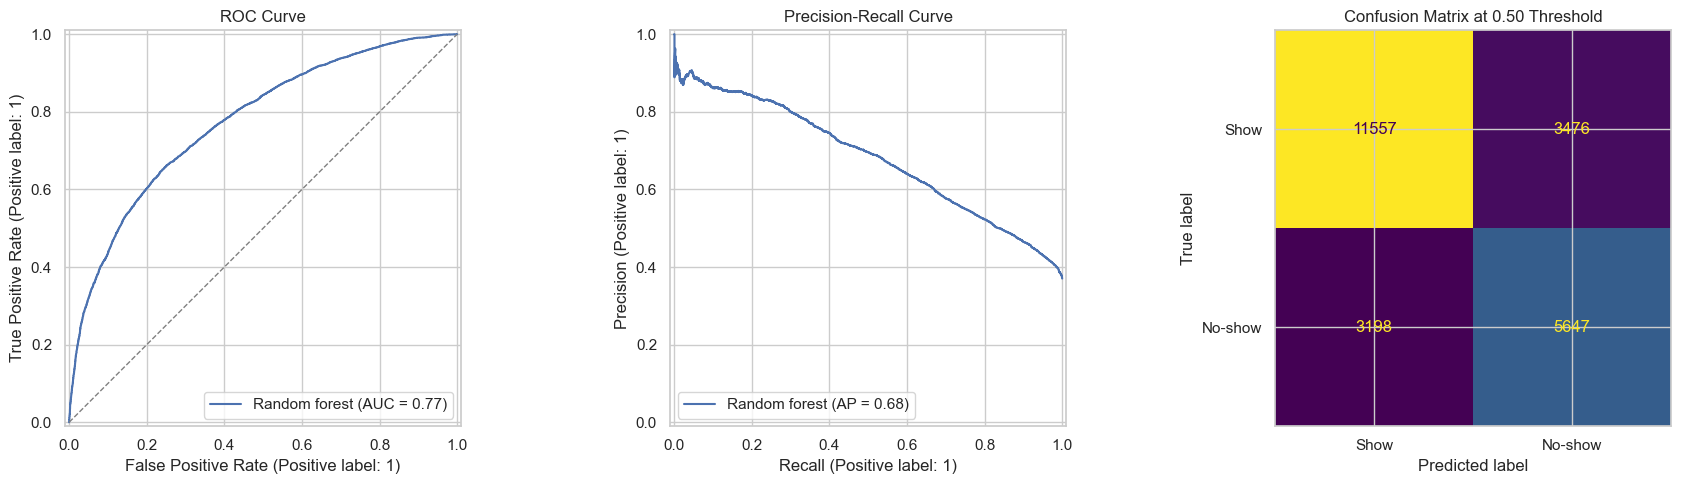

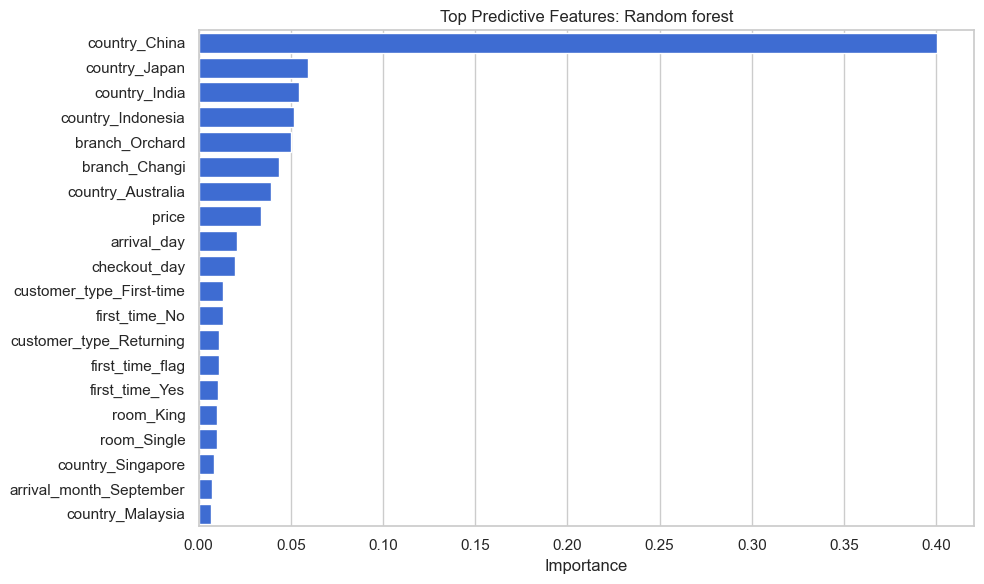

,feature,importance
0,country_China,0.400
1,country_Japan,0.059
2,country_India,0.054
3,country_Indonesia,0.051
4,branch_Orchard,0.050
5,branch_Changi,0.043
6,country_Australia,0.039
7,price,0.034
8,arrival_day,0.021
9,checkout_day,0.020


In [21]:
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

test_pred = (test_probability >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
RocCurveDisplay.from_predictions(y_test, test_probability, ax=axes[0], name=best_model_name)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, test_probability, ax=axes[1], name=best_model_name)
axes[1].set_title("Precision-Recall Curve")

ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred), display_labels=["Show", "No-show"]).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Confusion Matrix at 0.50 Threshold")
plt.tight_layout()
plt.show()

def get_feature_importance(pipeline, top_n=20):
    preprocessor = pipeline.named_steps["preprocess"]
    estimator = pipeline.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()

    if hasattr(estimator, "feature_importances_"):
        importance = estimator.feature_importances_
    elif hasattr(estimator, "coef_"):
        importance = np.abs(estimator.coef_).ravel()
    else:
        return pd.DataFrame(columns=["feature", "importance"])

    return (
        pd.DataFrame({"feature": feature_names, "importance": importance})
        .sort_values("importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

feature_importance = get_feature_importance(best_model)
if feature_importance.empty:
    print(f"{best_model_name} does not expose native feature importance.")
else:
    plt.figure(figsize=(10, 6))
    if sns:
        sns.barplot(data=feature_importance, y="feature", x="importance", color="#2563eb")
    else:
        plt.barh(feature_importance["feature"], feature_importance["importance"])
        plt.gca().invert_yaxis()
    plt.title(f"Top Predictive Features: {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
    display(feature_importance)

In [ ]:
model_score_columns = {
    "Logistic regression": "ml_risk_logistic_regression",
    "Decision tree": "ml_risk_decision_tree",
    "Random forest": "ml_risk_random_forest",
    "Extra trees": "ml_risk_extra_trees",
    "Gradient boosting": "ml_risk_gradient_boosting",
}

# Retain all cleaned booking rows, then append one no-show probability column per real ML model.
final_scored_df = eda.copy()
for score_col in model_score_columns.values():
    final_scored_df[score_col] = np.nan

for model_name, score_col in model_score_columns.items():
    if model_name not in fitted_models:
        raise KeyError(f"Expected fitted model not found: {model_name}")
    final_scored_df.loc[ml_data.index, score_col] = predict_positive_probability(fitted_models[model_name], X)

# Random Forest is the selected operational model for the dashboard risk score.
winning_model_name = "Random forest"
winning_score_col = model_score_columns[winning_model_name]
final_scored_df["risk_score"] = final_scored_df[winning_score_col]
final_scored_df["predicted_no_show_probability"] = final_scored_df[winning_score_col]

final_scored_df["risk_band"] = "Unassigned"
score_mask = final_scored_df["risk_score"].notna()
if score_mask.sum() >= 3:
    ranked_scores = final_scored_df.loc[score_mask, "risk_score"].rank(method="first")
    final_scored_df.loc[score_mask, "risk_band"] = pd.qcut(
        ranked_scores,
        q=3,
        labels=["Low", "Medium", "High"],
    ).astype(str)

if "price" in final_scored_df.columns:
    final_scored_df["price_numeric"] = pd.to_numeric(final_scored_df["price"], errors="coerce")
    final_scored_df["expected_revenue_at_risk"] = final_scored_df["price_numeric"].fillna(0) * final_scored_df["risk_score"]
else:
    final_scored_df["price_numeric"] = np.nan
    final_scored_df["expected_revenue_at_risk"] = np.nan

# writes the full scored dataset with all features and predictions to a new SQLite table for use in the dashboard and further analysis
final_scored_df.to_sql("booking_ml_scores", conn, if_exists="replace", index=False)

risk_band_summary = (
    final_scored_df.loc[score_mask]
    .groupby("risk_band", observed=False)
    .agg(
        bookings=(TARGET_COL, "size"),
        actual_no_show_rate=(TARGET_COL, "mean"),
        avg_predicted_no_show_probability=("predicted_no_show_probability", "mean"),
        expected_revenue_at_risk=("expected_revenue_at_risk", "sum"),
    )
    .reset_index()
)

top_risk_columns = [
    c for c in [
        "booking_id", "branch", "platform", "country", "room", "price",
        *model_score_columns.values(), "risk_score", "risk_band",
        "expected_revenue_at_risk", TARGET_COL,
    ]
    if c in final_scored_df.columns
]
top_high_risk_bookings = final_scored_df.sort_values(
    ["expected_revenue_at_risk", "risk_score"], ascending=False
).head(20)[top_risk_columns]

print(f"Persisted {len(final_scored_df):,} rows to SQLite table: booking_ml_scores")
display(risk_band_summary.style.format({
    "actual_no_show_rate": "{:.1%}",
    "avg_predicted_no_show_probability": "{:.1%}",
    "expected_revenue_at_risk": "{:,.2f}",
}))
display(top_high_risk_bookings.style.format({
    "price": "{:,.2f}",
    "ml_risk_logistic_regression": "{:.1%}",
    "ml_risk_decision_tree": "{:.1%}",
    "ml_risk_random_forest": "{:.1%}",
    "ml_risk_extra_trees": "{:.1%}",
    "ml_risk_gradient_boosting": "{:.1%}",
    "risk_score": "{:.1%}",
    "expected_revenue_at_risk": "{:,.2f}",
}))

Persisted 119,391 rows to SQLite table: booking_ml_scores


,risk_band,bookings,actual_no_show_rate,avg_predicted_no_show_probability,expected_revenue_at_risk
0,High,39797,64.4%,71.7%,"18,688,706.32"
1,Low,39797,14.0%,26.8%,"7,475,069.99"
2,Medium,39796,32.7%,43.6%,"9,907,819.75"


,booking_id,branch,platform,country,room,price,ml_risk_logistic_regression,ml_risk_decision_tree,ml_risk_random_forest,ml_risk_extra_trees,ml_risk_gradient_boosting,risk_score,risk_band,expected_revenue_at_risk,no_show
36876,100847,Orchard,Agent,China,nan,"2,072.72",65.3%,73.6%,67.7%,68.8%,54.9%,67.7%,High,"1,404.11",0.000000
48981,32970,Orchard,Website,China,nan,"2,066.61",63.5%,73.6%,67.6%,67.8%,55.1%,67.6%,High,"1,396.25",0.000000
12978,104735,Orchard,Email,China,nan,"2,041.05",56.7%,86.0%,68.0%,68.1%,50.2%,68.0%,High,"1,387.53",0.000000
89071,54734,Orchard,Email,China,President Suite,"2,070.01",71.2%,71.5%,65.5%,67.4%,51.7%,65.5%,High,"1,355.99",0.000000
71888,21769,Orchard,Website,China,President Suite,"2,061.12",66.4%,62.7%,65.2%,65.0%,50.3%,65.2%,High,"1,342.90",0.000000
36525,88467,Orchard,Email,China,President Suite,"2,001.62",67.7%,74.1%,66.9%,67.0%,51.5%,66.9%,High,"1,339.58",0.000000
14526,71634,Orchard,Website,China,President Suite,"2,025.18",66.4%,71.5%,66.0%,66.6%,51.0%,66.0%,High,"1,337.54",1.000000
72101,87073,Orchard,Website,China,nan,"1,968.51",65.1%,73.6%,67.4%,68.2%,54.9%,67.4%,High,"1,327.23",1.000000
113424,108215,Orchard,Website,China,President Suite,"2,017.52",69.4%,71.5%,65.7%,66.7%,51.7%,65.7%,High,"1,324.58",1.000000
97935,77489,Orchard,Agent,China,President Suite,"1,967.16",64.1%,74.1%,67.3%,66.5%,50.2%,67.3%,High,"1,324.54",1.000000


In [26]:
top_features_text = "native feature importance is not available for the selected model"
if "feature_importance" in globals() and not feature_importance.empty:
    top_features_text = ", ".join(feature_importance["feature"].head(5).astype(str))

best_valid = model_results.iloc[0]
best_test = test_metrics.iloc[0]
interpretation = f"""
### Task 2 Output Summary

- The best validation model is **{best_model_name}**, selected by PR-AUC with ROC-AUC as the tie-breaker.
- Validation performance: PR-AUC **{best_valid['pr_auc']:.3f}**, ROC-AUC **{best_valid['roc_auc']:.3f}**.
- Held-out test performance: PR-AUC **{best_test['pr_auc']:.3f}**, ROC-AUC **{best_test['roc_auc']:.3f}**, recall **{best_test['recall']:.3f}**, precision **{best_test['precision']:.3f}**.
- The strongest available predictors are: {top_features_text}.
- Operationally, use this model to rank bookings by no-show probability, then prioritize high-probability and high-price bookings for reminders, reconfirmation, deposit tests, or controlled overbooking review.
- Limitations: the dataset does not include booking lead time, cancellation policy, payment status, loyalty history, or previous customer behavior, so production performance should be monitored after deployment.
"""
display(Markdown(interpretation))


### Task 2 Output Summary

- The best validation model is **Random forest**, selected by PR-AUC with ROC-AUC as the tie-breaker.
- Validation performance: PR-AUC **0.676**, ROC-AUC **0.771**.
- Held-out test performance: PR-AUC **0.681**, ROC-AUC **0.775**, recall **0.638**, precision **0.619**.
- The strongest available predictors are: country_China, country_Japan, country_India, country_Indonesia, branch_Orchard.
- Operationally, use this model to rank bookings by no-show probability, then prioritize high-probability and high-price bookings for reminders, reconfirmation, deposit tests, or controlled overbooking review.
- Limitations: the dataset does not include booking lead time, cancellation policy, payment status, loyalty history, or previous customer behavior, so production performance should be monitored after deployment.
